# PLOT

In [1391]:
import numpy as np
from astropy.io import ascii
import matplotlib.pyplot as plt
def grmonty(file):
    """
    Reads SEDs in the format provided by grmonty. Ported from 
    the original SM script `plspec.m` provided by J. Dolence.
    
    Returns:
        lognu: Logarithmic frequency values
        ll: Logarithmic luminosity values in shape (6, s['colx'].shape)
    """
    LSUN = 3.827e33
    CL = 2.99792458e10
    ME = 9.1093826e-28
    HPL =  6.6260693e-27
    # Read the file using ascii
    s = ascii.read(file, format='no_header')


    # Array conversions for luminosity values (log10)
    ll = np.zeros((6, len(s)))  # Pre-allocate the array with shape (6, s['colx'].shape)
    ll[0] = np.array(s['col2'] * LSUN)
    ll[1] = np.array(s['col8'] * LSUN)
    ll[2] = np.array(s['col14']* LSUN)
    ll[3] = np.array(s['col20']* LSUN)
    ll[4] = np.array(s['col26']* LSUN)
    ll[5] = np.array(s['col32']* LSUN)

    # Compute log frequency (log(nu)) values
    nu = np.array(10**s['col1'] * (ME * CL**2/HPL))
    #print(nu)
    # Return log(nu) and ll array
    return nu, ll
nu, nuLnu = grmonty('../output/test_thick.spec')
domega_array = np.array([4.254826e-1, 1.247635e0, 1.985301e0, 2.588526e0, 3.016463e0, 3.240132e0])


In [1392]:
import numpy as np
from scipy.special import kn  # For the modified Bessel function
from scipy.integrate import quad  # For integration

# Constants
M_SQRT2 = np.sqrt(2)
EE = 4.80320680e-10  # Electron charge in cgs
ME = 9.1093826e-28 # Electron mass in grams
CL = 2.99792458e10   # Speed of light in cm/s
JCST = M_SQRT2 * EE**3 / (27 * ME * CL**2)
CST = 1.88774862536  # 2^(11/12)

THETAE_MIN = 0.3

# Parameters for emissivity tables
KMIN = 0.002
KMAX = 1e7
TMIN = 0.3
TMAX = 1e2
N_ESAMP = 2500
EPSABS = 0.
EPSREL = 1e-6
dlT = 1/(np.log(TMAX/TMIN)/N_ESAMP)
lT_min = np.log(TMIN)
# Initialize tables
F_table = np.zeros(N_ESAMP + 1)
K2_table = np.zeros(N_ESAMP + 1)

def jnu_integrand(th, K):
    """Integrand for the emissivity calculation."""
    sth = np.sin(th)
    x = K / sth
    if sth < 1.e-150 or x > 2.e8:
        return 0.
    #print("Inside integrand: sth =", sth, "and x = ", x)
    return sth**2 * (np.sqrt(x) + CST * x**(1. / 6.))**2 * np.exp(-x**(1. / 3.))

def init_emiss_tables():
    """Initialize emissivity and Bessel function tables."""
    global F_table, K2_table
    
    dlK = np.log(KMAX / KMIN) / N_ESAMP
    dlT = np.log(TMAX / TMIN) / N_ESAMP

    # Calculate F(K) table
    for k in range(N_ESAMP + 1):
        K = np.exp(k * dlK + np.log(KMIN))
        result, err = quad(jnu_integrand, 0, np.pi / 2, args=(K), epsabs=EPSABS, epsrel=EPSREL)
        F_table[k] = np.log(4 * np.pi * result)
        #print("K =", K, "result = ", result, "log= ", np.log(4 * np.pi * result))

    # Calculate K2(T) table (Bessel function values)
    for k in range(N_ESAMP + 1):
        T = np.exp(k * dlT + np.log(TMIN))
        K2_table[k] = np.log(kn(2, 1. / T))

    # Avoid divisions later
    global inv_dlK, inv_dlT
    inv_dlK = 1. / dlK
    inv_dlT = 1. / dlT


def K2_eval(Thetae):
    """Evaluate K2 using precomputed values and interpolation."""
    # Check if Thetae is less than the minimum or greater than the maximum
    if Thetae < TMIN:
        return 0.
    elif Thetae > TMAX:
        return 2. * Thetae * Thetae  # As per CUDA code

    if(Thetae == 100):
        return 1.999950006839e+04
    # Perform linear interpolation for the value of K2
    return linear_interp_K2(Thetae)

def linear_interp_K2(Thetae):
    """Linear interpolation for K2 evaluation."""
    # Calculate the index for the log of Thetae in the precomputed table
    lT = np.log(Thetae)
    
    # Compute the fractional index for interpolation
    di = (lT - lT_min) * inv_dlT  # Using inverse of dlT for better performance
    i = int(di)
    di = di - i  # Get the fractional part
    print(i, di)
    # Perform linear interpolation between the two closest table entries
    return np.exp((1. - di) * K2_table[i] + di * K2_table[i + 1])
    
KFAC = 9 * np.pi * ME * CL / EE

def linear_interp_F(K):
    """Linearly interpolate F_table for a given K value."""
    # Calculate the log of K and map it to the table index
    lK_min = np.log(KMIN)
    dlK = np.log(KMAX / KMIN) / N_ESAMP
    inv_dlK = 1.0 / dlK

    lK = np.log(K)
    di = (lK - lK_min) * inv_dlK
    i = int(di)
    di -= i  # Fractional part for interpolation

    # Boundary check to ensure interpolation remains within table range
    if i < 0 or i >= N_ESAMP:
        return 0.  # Return 0 if K is out of bounds (handled separately in F_eval)

    # Interpolate linearly between F_table[i] and F_table[i+1]
    result = np.exp((1.0 - di) * F_table[i] + di * F_table[i + 1])
    #print("Linear_interpo =", result, di, i);
    return result

def F_eval(Thetae, Bmag, nu):
    """Evaluate F using precomputed tables or approximation based on K."""
    # Calculate K based on input parameters
    K = KFAC * nu / (Bmag * Thetae**2)
    #print("K = ", K)
    if K > KMAX:
        # If K is beyond the table's range, return 0 as an approximation
        return 0.
    elif K < KMIN:
        # Use approximation for small K values
        x = K**(1 / 3)
        return x * (37.67503800178 + 2.240274341836 * x)
    else:
        # Use linear interpolation for values within table range
        return linear_interp_F(K)

# Example usage of F_eval within int_jnu calculation
def int_jnu(Ne, Thetae, Bmag, nu):
    """Calculate emissivity jnu using precomputed tables and F_eval, allowing nu to be an array."""
    # Ensure nu is an array
    nu = np.atleast_1d(nu)  # This converts scalars to a 1D array

    # Handle cases where Thetae is below the minimum threshold
    if Thetae < THETAE_MIN:
        return np.zeros_like(nu)

    # Get K2 using precomputed tables
    K2 = K2_eval(Thetae)
    if K2 == 0.:
        return np.zeros_like(nu)
    K2 = 1.999950006839e4
    # Calculate j_fac only once since it doesn't depend on nu
    j_fac = Ne * Bmag * Thetae**2 / K2

    # Compute F_eval for each value in the nu array
    F_vals = np.array([F_eval(Thetae, Bmag, n) for n in nu])
    # Calculate jnu for each nu value
    jnu_vals = JCST * j_fac * F_vals

    # If input was a scalar, return scalar output; otherwise, return array
    return jnu_vals[0] if jnu_vals.size == 1 else jnu_vals

# Initialize tables before calculations
init_emiss_tables()

/tmp/ipykernel_390757/1231658380.py:30: RuntimeWarning: overflow encountered in exp
  result = (2.0 * HPL * nu * nu * nu/ (CL * CL)) / (np.exp(x) - 1.0)
/tmp/ipykernel_390757/1231658380.py:36: RuntimeWarning: invalid value encountered in divide
  alpha_nu_values = (j_nu_values)/(Bnu(nu, 100))
/tmp/ipykernel_390757/1231658380.py:40: RuntimeWarning: invalid value encountered in divide
  alpha = np.float128(jnu(1e20, nu, 1, 100))/np.float128(Bnu(nu,100))
/tmp/ipykernel_390757/1231658380.py:47: RuntimeWarning: invalid value encountered in scalar divide
  Luminosity_analytic[i] = dv * int_jnu(1e20, 100, 1, nu[i])/(alpha[i]) * (alpha[i] + alpha[i]**2/2 + alpha[i]**3/6 + alpha[i]**4/24)


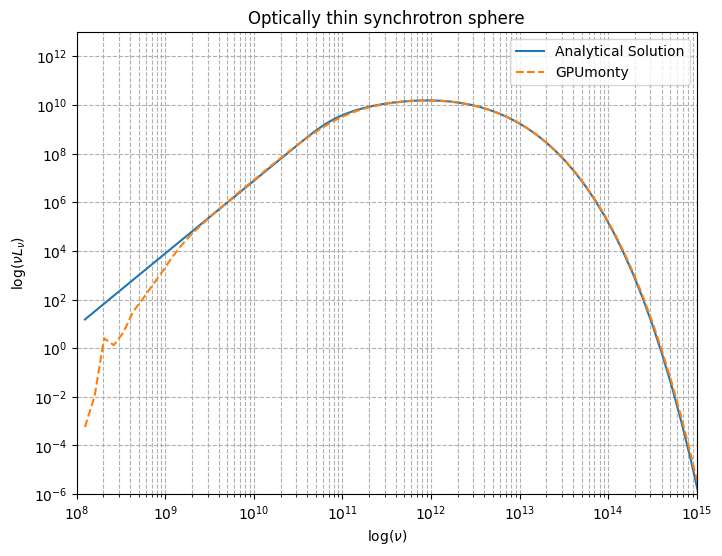

In [1393]:
from scipy.special import kn
def jnu(ne, nu, B, thetae):
    sin_value = 1
    nus = (2/9) * (EE * B/(2 * np.pi * ME * CL)) * thetae**2 * sin_value
    X = nu/nus
    K2 = kn(2, 1/thetae)
    #K2 = 2 * thetae**2
    factor =  np.sqrt(2) * np.pi * EE**2 * ne * nus/(3 * CL * K2)
    return factor * (X**(1/2) + 2**(11/12) * X**(1/6))**2 * np.exp(-X**(1/3))
# Frequency range from 1e8 Hz to 1e16 Hz (in logarithmic scale)
# Calculate synchrotron emissivity for each frequency

def Bnu(nu, Thetae):
    """
    Calculates the Planck function B_nu at a given frequency nu and electron temperature Thetae.
    
    Parameters:
    nu (array-like): Frequency in Hz (can be an array).
    Thetae (float): Dimensionless electron temperature (Thetae = kT_e / m_e c^2).
    
    Returns:
    array: B_nu values for the given frequencies.
    """
    # Calculate x for the entire array
    x = HPL * nu / (ME * CL * CL * Thetae)

    # Initialize result array
    result = np.zeros_like(x)

    result = (2.0 * HPL * nu * nu * nu/ (CL * CL)) / (np.exp(x) - 1.0)
    return result
    
#print("Optical depth at nu =", 1e9, "is:",(jnu(1e13, 1e15, 1, 100))/(Bnu(1e15, 100)))
j_nu_values = int_jnu(1e20, 100, 1, nu)#jnu(1e20, nu, 1, 100)
j_nu_values_avg = int_jnu(1e20, 100, 1, nu)
alpha_nu_values = (j_nu_values)/(Bnu(nu, 100))

R = 1 * L_UNIT
dv = 4/3 * np.pi * R**3
alpha = np.float128(jnu(1e20, nu, 1, 100))/np.float128(Bnu(nu,100))
# Loop through each value of alpha and apply the appropriate formula
exp_approx = np.zeros_like(nu)  # Assuming nu has the same length as alpha
Luminosity_analytic = np.zeros_like(nu)
for i in range(len(alpha)):
    if alpha[i] < 1e-3:
        # Using the Taylor expansion approximation for small alpha
        Luminosity_analytic[i] = dv * int_jnu(1e20, 100, 1, nu[i])/(alpha[i]) * (alpha[i] + alpha[i]**2/2 + alpha[i]**3/6 + alpha[i]**4/24)
    else:
        # Standard exponential for larger alpha
        exp_approx[i] = np.exp(-alpha[i])
        Luminosity_analytic[i] = dv * (int_jnu(1e20, 100, 1, nu[i])/(alpha[i]) * (1 - exp_approx[i]))

        
#Luminosity_analytic = dv * (int_jnu(1e20, 100, 1, nu)/(int_jnu(1e20, 100, 1, nu)/Bnu(nu,100))) * (1 - np.exp(- (int_jnu(1e20, 100, 1, nu)/Bnu(nu,100)) * 1 ))

Luminosity_analytic_2 = dv * j_nu_values_avg
nu_luminosity_analytic = nu * Luminosity_analytic
nu_luminosity_analytic_2 = nu * Luminosity_analytic_2

# Plot jnu vs nu
plt.figure(figsize=(8, 6))
plt.plot(nu, nu_luminosity_analytic, linestyle='-', label = 'Analytical Solution')
#plt.plot(nu, nu_luminosity_analytic_2, linestyle='-', label = 'Analytical Solution')

#plt.plot(nu, (nuLnu * domega_array[:,np.newaxis]/(4*np.pi)).sum(0), linestyle='-', label = 'GPUmonty')
#plt.plot(nu, (nuLnu[5]/(4 * np.pi) * domega_array[:,np.newaxis]).sum(0), linestyle='-', label = 'GPUmonty')
#plt.plot(grmonty_nu, (grmonty_nuLnu/(4 * np.pi)).sum(0), linestyle='-', label = 'Grmonty')z
#plt.plot(grmonty_nu, (grmonty_nuLnu/(16 * np.pi)).sum(0), linestyle='-', label = 'Grmonty')
plt.plot(nu, (nuLnu* domega_array[:,None]/(4 * np.pi)).sum(0), linestyle='--', label = 'GPUmonty')
#plt.plot(nu_check, (nuLnu_check/(4 * np.pi)).sum(0), linestyle='--', label = 'GPUmonty_check')

#plt.plot(grmonty_nu_all, (grmonty_nuLnu_all/(16 * np.pi)).sum(0), linestyle='-', label = 'Grmonty 1')

#x = (nuLnu * domega/(4*np.pi)).sum(0)
#plt.plot(lognu, np.log10(nu_luminosity_analytic) - (s.ll), label = 'difference')
#gpumonty_nulognu = 10**(s.ll - np.log10(3.83e33))
#epsilon = 1/lognu * (np.abs(gpumonty_nulognu - nu_luminosity_analytic)/nu_luminosity_analytic * np.gradient(lognu)).sum(-1)
plt.ylim(1e-6,1e13)
plt.xlim(1e8,1e15)
plt.yscale('log')
plt.xscale('log')
#plt.yticks([1e-11, 1e-10,1e-9, 1e-8, 1e-7, 1e-6, 1e-5,1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2, 1e3, 1e4,1e5])
plt.xlabel(r"$\log(\nu)$")
plt.legend()
plt.ylabel(r"$\log(\nu L_\nu)$")
plt.title('Optically thin synchrotron sphere')
plt.grid(True, which="both", ls="--")
plt.show()

In [1285]:
# Given terms
term1 = int_jnu(1e20, 100, 1, 1e15) #jnu
term2 = jnu(1e20, 1e15, 1, 100) / Bnu(1e15, 100) #alpha
term3 = np.float128(1 - np.exp(-np.float128(term2) * 1))#(1 - e)
result = dv * 1e15 * (term1 / term2) * term3

# Print each term with scientific notation
print(f"i: {i:3d}")
print(f"nu[i]: {1.908e+14:.3e}")
print(f"term1 (int_jnu): {term1:.3e}")
print(f"term2 (jnu / Bnu): {term2:.3e}")
print(f"term3 (1 - exp(-term2 * 0.5)): {term3:.3e}")
print(f"result: {result:.3e}")


i: 199
nu[i]: 1.908e+14
term1 (int_jnu): 5.238e-22
term2 (jnu / Bnu): 8.140e-28
term3 (1 - exp(-term2 * 0.5)): 0.000e+00
result: 0.000e+00


In [1286]:
1 - np.exp(-np.float128(8e-28))

0.0

/tmp/ipykernel_390757/1231658380.py:30: RuntimeWarning: overflow encountered in exp
  result = (2.0 * HPL * nu * nu * nu/ (CL * CL)) / (np.exp(x) - 1.0)
/tmp/ipykernel_390757/3422685715.py:16: RuntimeWarning: invalid value encountered in divide
  alpha_nu_values = (j_nu_values)/(Bnu(nu, 100))
/tmp/ipykernel_390757/3422685715.py:19: RuntimeWarning: invalid value encountered in divide
  Luminosity_analytic = dv * (int_jnu(1e20, 100, 1, nu)/(jnu(1e20, nu, 1, 100)/Bnu(nu,100))) * (1 - np.exp(- (jnu(1e20, nu, 1, 100)/Bnu(nu,100)) * 1 ))
/tmp/ipykernel_390757/3422685715.py:56: RuntimeWarning: divide by zero encountered in divide
  relative_diff2 = (y_analdata - y_simdata) / y_analdata
/tmp/ipykernel_390757/3422685715.py:56: RuntimeWarning: invalid value encountered in divide
  relative_diff2 = (y_analdata - y_simdata) / y_analdata


(200,)
nan


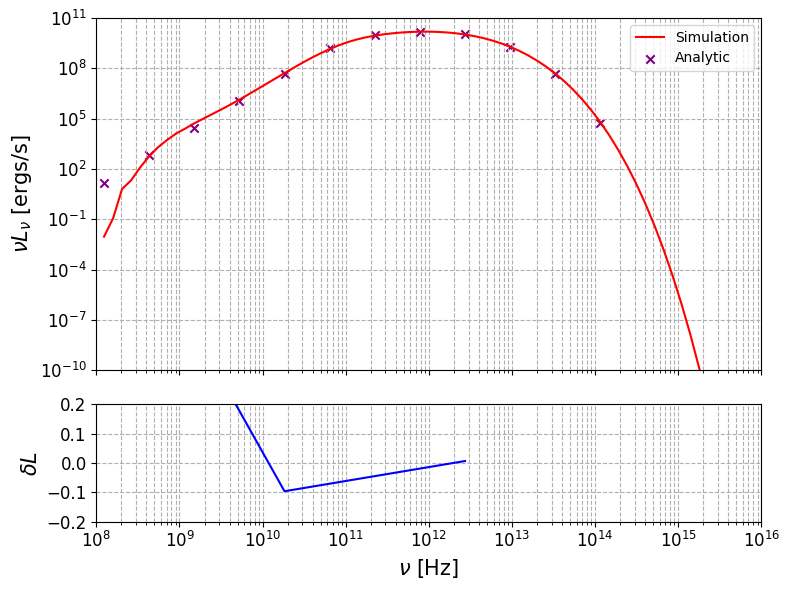

In [1390]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import kn

# Synchrotron emissivity function
def jnu(ne, nu, B, thetae):
    sin_value = 1
    nus = (2/9) * (EE * B/(2 * np.pi * ME * CL)) * thetae**2 * sin_value
    X = nu / nus
    factor = np.sqrt(2) * np.pi * EE**2 * ne * nus / (3 * CL * kn(2, 1/thetae))
    return factor * (X**(1/2) + 2**(11/12) * X**(1/6))**2 * np.exp(-X**(1/3))

#j_nu_values = int_jnu(1e13, 100, 1, nu)
j_nu_values = jnu(1e20, nu, 1, 100)
#j_nu_values = int_jnu(1e20, 100, 1, nu)
alpha_nu_values = (j_nu_values)/(Bnu(nu, 100))
R = 1 * L_UNIT
dv = 4/3 * np.pi * R**3
Luminosity_analytic = dv * (int_jnu(1e20, 100, 1, nu)/(jnu(1e20, nu, 1, 100)/Bnu(nu,100))) * (1 - np.exp(- (jnu(1e20, nu, 1, 100)/Bnu(nu,100)) * 1 ))
#Luminosity_analytic = np.float128(dv * Bnu(nu,100) * (1 - np.exp(-alpha_nu_values * 1 )))
nu_luminosity_analytic = nu * Luminosity_analytic


# Create figure and subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Upper plot: Analytical Solution and GPUmonty data
#ax1.plot(nu, nu_luminosity_analytic, linestyle='-', marker='x', label='Analytical Solution')
#x = (nuLnu * domega_array[:,np.newaxis]/(4 * np.pi) * 3).sum(0)
#ax1.plot(nu, x, label='GPUmonty Data')
#ax1.plot(nu, (nuLnu * domega_array[:,np.newaxis]/(4 * np.pi) * 3).sum(0), label='GPUmonty Data')
xdata = nu
#y_semianaldata = (grmonty_nuLnu_all/(16 * np.pi)).sum(0)
y_simdata = (nuLnu* domega_array[:,None]/(4* np.pi)).sum(0)
y_analdata = nu_luminosity_analytic
ax1.plot(nu, y_simdata, linestyle='-', label = 'Simulation', color = 'red')
print(y_analdata.shape)
ax1.scatter(nu[::5], y_analdata[::5], marker = 'x', label = 'Analytic', color = 'purple')
#ax1.plot(grmonty_nu_all, y_semianaldata, linestyle = '--', label = 'semi-analytic', color = 'green')


ax1.set_ylim(1e-10,1e11)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylabel(r"$\nu L_\nu$ [ergs/s]", fontsize = 15)
#ax1.set_title('Optically Thin Synchrotron Sphere')
ax1.grid(True, which="both", ls="--")
ax1.set_xlim(1e8, 1e16)
ax1.tick_params(axis='both', which='major', labelsize=12)  # Adjust major tick size

ax1.legend()

# Lower plot: Relative difference between analytical and GPUmonty data
#relative_diff = np.abs(nu_luminosity_analytic - x) / nu_luminosity_analytic
#relative_diff = np.abs(y_semianaldata - y_simdata) / y_analdata
relative_diff2 = (y_analdata - y_simdata) / y_analdata
#ax2.plot(xdata, relative_diff, color='k', label = 'semi')
ax2.plot(xdata[::20], relative_diff2[::20], color='b', label = 'analy')

#ax2.legend()
ax2.set_xscale('log')
ax2.set_xlabel(r"$\nu$ [Hz]", fontsize = 15)
ax2.set_ylabel(r'$\delta L$', fontsize = 15)
ax2.grid(True, which="both", ls="--")
#ax2.set_yticks([0,0.1,0.2,0.3,0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
ax2.set_yticks([-0.2, -0.1, 0.0, 0.1, 0.2])
print((relative_diff2[:1800]).mean(0))
ax2.set_ylim(-0.2, 0.2)
ax2.tick_params(axis='both', which='major', labelsize=12)  # Adjust major tick size

# Display the plots
plt.tight_layout()
#plt.savefig('./thin_synch_spectrum.pdf', dpi=300, bbox_inches='tight')
plt.show()


y_simdata = np.zeros((7, 5000))
for i in range(3,9):
    nu, nuLnu = grmonty('../output/thin_'+str(i)+'.spec')
    y_simdata[i-3] = (nuLnu* domega_array[:,None]/(4* np.pi)).sum(0)
print(nu.shape)
j_nu_values = int_jnu(1e13, 100, 1, nu)
R = 1 * L_UNIT
dv = 4/3 * np.pi * R**3
y_analdata = dv * j_nu_values * nu

epsilon = np.zeros((6))
for i in range(3,9):
    epsilon[i-3] = 1/np.log(1e16/1e7) * (np.abs(y_simdata[i-3,:1800] - y_analdata[:1800]) * 0.01/(y_analdata[:1800])).sum(0)
epsilon

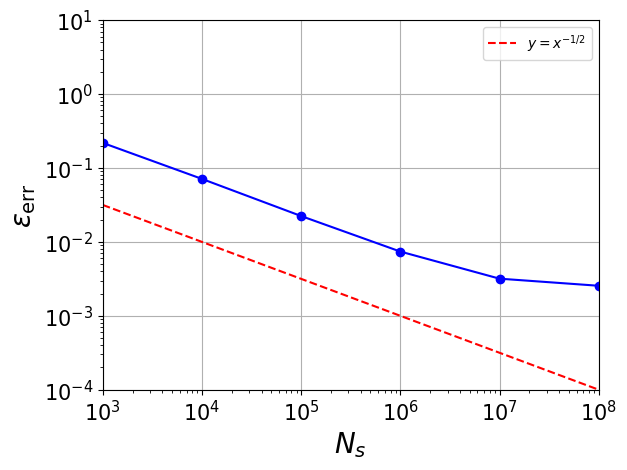

In [786]:
import matplotlib.pyplot as plt
import numpy as np
x_data_epsilon = np.array((1e3,1e4,1e5,1e6,1e7,1e8))

# Plot the data
plt.plot(x_data_epsilon, epsilon, linestyle = '-', marker = 'o', color = 'b')

# Plot the x^{-1/2} line for comparison
plt.plot(x_data_epsilon, x_data_epsilon**(-1/2), label=r'$y = x^{-1/2}$', linestyle='--', color='red')

# Formatting
plt.yticks([1e-3, 1e-2, 1e-1])
plt.ylim(1e-4, 10)
plt.xlim(1e3, 10**(8))
plt.yscale('log')
plt.xscale('log')

# Add labels
plt.ylabel(r'$\epsilon_{\rm err}$', fontsize=20)
plt.xlabel(r'$N_s$', fontsize=20)

# Adjust tick size
plt.tick_params(axis='both', which='major', labelsize=15)  # Adjust major tick size
plt.tick_params(axis='both', which='minor', labelsize=10)  # Adjust minor tick size (if you want)

# Enable grid
plt.grid(True)

# Show the plot
plt.legend()
plt.savefig('./thin_synch_conv.pdf', dpi=300, bbox_inches='tight')

plt.show()


#from gpumonty
import nmmn.sed
import matplotlib.pyplot as plt
s=nmmn.sed.SED()

s.grmonty('../gpumonty/output/spherical_test.specmake')
plt.title("GPUMonty", fontsize = 15)

plt.xlim(10, 14)
plt.ylim(1e-3, 1e3)
F_nu = 10**(s.ll)/10**(s.lognu) * 1/(4 * np.pi * 2.469e22)
plt.plot(s.lognu, F_nu)
plt.yscale('log')

        Use "format" instead. [nmmn.sed]


FileNotFoundError: [Errno 2] No such file or directory: '/home/pedro/gpumonty/output/gpumonty_hamr_0'

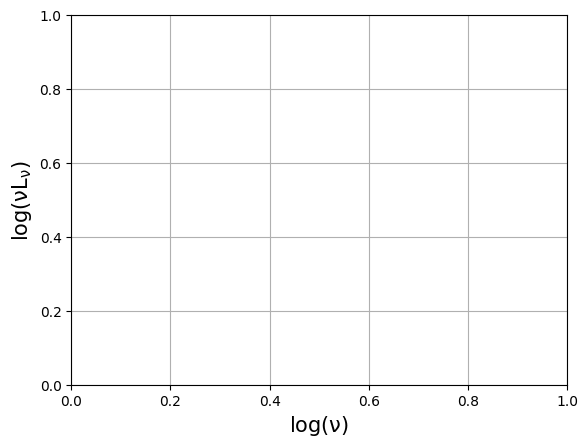

In [1361]:
#from gpumonty
import nmmn.sed
import matplotlib.pyplot as plt
import numpy as np
number_of_outputs = 10
plt.grid(True)
ydata_gpu = np.zeros((number_of_outputs, 200))
xdata_gpu = np.zeros((number_of_outputs, 200))
plt.ylabel(r'$\rm log(\nu L_\nu)$', fontsize = 15)
plt.xlabel(r'$\rm log(\nu)$', fontsize = 15)
s=nmmn.sed.SED()
cmap = plt.get_cmap('CMRmap')
for i in range(number_of_outputs):
    s.grmonty('/home/pedro/gpumonty/output/gpumonty_hamr_'+str(i))
    xdata_gpu[i] = s.lognu
    ydata_gpu[i] = s.ll
#for i in range(number_of_outputs):
    #plt.plot(xdata_gpu.mean(0), ydata_gpu[i],'--', color=cmap(i / number_of_outputs))

plt.plot(xdata_gpu.mean(0), ydata_gpu.mean(0), linestyle = '--',lw = 3, color = 'black', label = 'GPUmonty Averaged')

for i in range(number_of_outputs):
    s.grmonty('/home/pedro/grmonty_original/grmonty/output/grmonty_original_'+str(i))
    xdata_gpu[i] = s.lognu
    ydata_gpu[i] = s.ll

plt.plot(xdata_gpu.mean(0), ydata_gpu.mean(0), linestyle = '--',lw = 3, color = 'red', label = 'GRmonty Averaged')

#plt.xlim(13, 25)
#plt.ylim(32, 38)
plt.legend(fontsize = 15)
plt.title("GPUmonty averaged 10 runs")


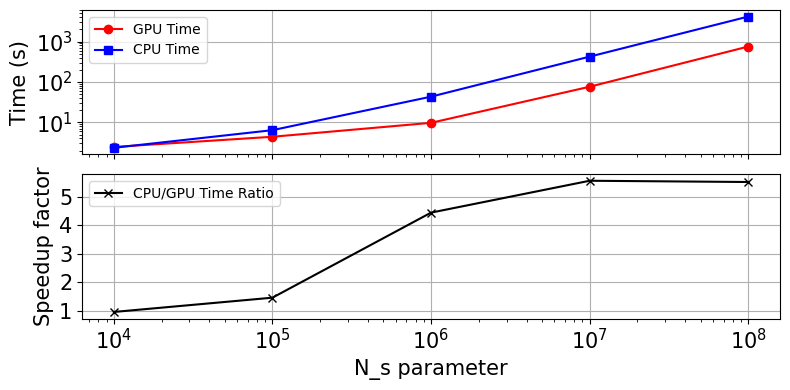

In [1363]:
import matplotlib.pyplot as plt
import numpy as np

# Data
problem_sizes = [1e4, 1e5, 1e6, 1e7, 1e8]
gpu_times = [2.46,  4.40, 9.74, 76.24, 754.35]  # in seconds
cpu_times = [2.35, 6.41, 43.29, 424.24, 4164.30]  # in seconds

# Calculate GPU/CPU ratio
gpu_cpu_ratio = np.array(cpu_times) / np.array(gpu_times)

# Create a figure and axis objects for the subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 4), sharex=True)

# Plot 1: Time vs Problem Size
ax1.plot(problem_sizes, gpu_times, label="GPU Time", marker='o', color = 'red')
ax1.plot(problem_sizes, cpu_times, label="CPU Time", marker='s', color = 'blue')
ax1.set_ylabel("Time (s)", fontsize = 15)
ax1.legend()
ax1.grid(True)
ax1.tick_params(axis='both', which='major', labelsize=15)  # Adjust major tick size
ax1.set_yscale('log')
# Plot 2: GPU/CPU Speedup Ratio vs Problem Size
ax2.set_yticks((1,2,3,4,5))
ax2.plot(problem_sizes, gpu_cpu_ratio, label="CPU/GPU Time Ratio", color='black', marker='x')
ax2.set_xlabel("N_s parameter", fontsize = 15)
ax2.set_ylabel("Speedup factor", fontsize = 15)
ax2.tick_params(axis='both', which='major', labelsize=15)  # Adjust major tick size
ax2.legend()
ax2.grid(True)
ax2.set_xscale('log')
# Display the plot
plt.tight_layout()
plt.savefig('./speedup_factor.pdf', dpi=300, bbox_inches='tight')
plt.show()


# Optically thin sphere

In [1364]:
import numpy as np
#Constants
#MBH = 4.1e6
#M_UNIT = 4.1e19  # Mass unit, derived from rho_scale
M_UNIT = 1  # Mass unit, derived from rho_scale

# Physical constants
GNEWT = 6.6742e-8  # Gravitational constant in cm^3/g/s^2
MSUN = 1.989e33  # Solar mass in grams
CL = 2.99792458e10  # Speed of light in cm/s
MP = 1.67262171e-24	  # Proton mass in grams
ME = 9.1093826e-28  # Electron mass in grams
EE = 4.80320680e-10
SIGMA_THOMPSON = 0.665245873e-24
HPL = 6.6260693e-27

MBH = (CL**2)/(GNEWT * MSUN) # Black hole mass in solar masses
MBH = 6.77e-6
#MBH = 10
# Derived units
L_UNIT = GNEWT * MBH * MSUN / (CL ** 2)  # Unit of length
T_UNIT = L_UNIT / CL  # Unit of time
RHO_UNIT = M_UNIT / (L_UNIT ** 3)  # Unit of density
U_UNIT = RHO_UNIT * CL ** 2  # Unit of energy density
B_UNIT = CL * np.sqrt(4. * np.pi * RHO_UNIT)  # Unit of magnetic field
NE_UNIT = RHO_UNIT / (MP + ME)  # Unit of electron number density
print("L_UNIT:", L_UNIT)
print("MBH:", MBH)
print("B_UNIT:", B_UNIT)

L_UNIT: 0.9999568564635455
MBH: 6.77e-06
B_UNIT: 106280537234.06927


In [1384]:
import numpy as np
import tqdm as tqdm
# Function to generate grid with different number of radial and theta cells
exponential_coordinates = 1
def generate_grid(cells_r, cells_th):
    Rin = 1e-3
    Rout = 2
    # Generate radial component (logarithmic space from Rin to Rout)
    if(exponential_coordinates):
        startx1 = np.log(np.float64(Rin))
        stopx1 = np.log(np.float64(Rout))
        step = (np.log(Rout) - np.log(Rin))/(cells_r)
    else:
        startx1 = np.float64(Rin)
        stopx1 = np.float64(Rout)
        step = (Rout - Rin)/(cells_r)
        
    x1 = np.arange(startx1, stopx1, step)
    if(exponential_coordinates):
        radial = np.exp(x1)
    else:
        radial = x1
    
    dx1 = (stopx1 - startx1)/(cells_r)
    # Generate theta component (linear space from 0 to pi)
    startx2 = np.float64(0.01)
    stopx2 = np.float64(np.pi)
    x2 = np.arange(startx2, stopx2, (stopx2 - startx2)/cells_th)
    theta = x2
    dx2 = (stopx2 - startx2)/(cells_th)
    # Create 2D grids for both components (use only the centers of the cells)
    #radial_centers = 0.5 * (radial[1:] + radial[:-1])
    #theta_centers = 0.5 * (theta[1:] + theta[:-1])
    
    # Create 2D grids for radial and theta values
    radial_grid, theta_grid = np.meshgrid(radial, theta, indexing='ij')
    
    # Create 2D grids for x1 and x2 with the same shape as radial_grid and theta_grid
    x1_grid, x2_grid = np.meshgrid(x1, x2, indexing='ij')
    
    # Return the meshgrid, and also x1_grid and x2_grid
    return radial_grid, theta_grid, x1_grid, x2_grid, dx1, dx2, startx1, stopx1, startx2, stopx2

# Example usage:
cells_r = 4096
cells_th = 256

# Generate the grid and return x1, x2
radius_grid, theta_grid, x1_grid, x2_grid, dx1, dx2, startx1, stopx1, startx2, stopx2 = generate_grid(cells_r, cells_th)

dx3 = np.float64(2 * np.pi)
startx3 = np.float64(np.pi * 2)
spin = np.float64(0)
gam = np.float64(13/9)
t = np.float64(13.49595)
print("dx1 = ", dx1)
print("dx2 = ", dx2)
print("dx3 = ", dx3)
print("General Shape = ", x1_grid.shape)
print("x1_min = ",np.min(x1_grid))

print("x1_max = ",np.max(x1_grid))
print("x2_max = ",np.max(x2_grid))

print("R_max = ", np.max(radius_grid))

dx1 =  0.0018556890770366412
dx2 =  0.01223278380308513
dx3 =  6.283185307179586
General Shape =  (4096, 256)
x1_min =  -6.907755278982137
x1_max =  0.6912914914813477
x2_max =  3.1293598697867084
R_max =  1.9962920632956767


In [1385]:
sphere_r = 1
def rho_spherical_cloud(radius_grid, ne_value, ne_unit = NE_UNIT, sphere_radius = sphere_r):
    rho_grid = np.zeros(radius_grid.shape)
    rho_grid[:,:] = ne_value/ne_unit
    mask = radius_grid > sphere_radius
    rho_grid[mask] = 0
    return rho_grid
    
def B_spherical_cloud(radius_grid, theta_grid, value = 1, sphere_radius = sphere_r):
    Br = np.zeros(radius_grid.shape)
    Bth = np.zeros(radius_grid.shape)
    
    if(exponential_coordinates):
        Br = value * np.cos(theta_grid)/(radius_grid)
    else:
        Br = value * np.cos(theta_grid)

    Bth = - value * np.sin(theta_grid)/(radius_grid)
    mask = radius_grid > sphere_radius
    Br[mask] = 0
    Bth[mask] = 0
    return Br, Bth

def ud_func(radius_grid, sphere_radius = sphere_r):
    ud = np.zeros(radius_grid.shape)
    ud[:,:] = 1
    mask = radius_grid< sphere_radius
    ud[mask] = 1;
    return ud

def calc_gdet(radius, theta):
    return np.sqrt(- (- radius**4 * np.sin(theta)**2))


In [1386]:
#GRMONTY TEST
Thetae0 = 100
B_value = 1
ne_value = 1e20
thetae_unit = 2.244186585525e+02

rho_grid = np.zeros(radius_grid.shape)
rho_grid[:,:] = rho_spherical_cloud(radius_grid, ne_value)
gdet = calc_gdet(radius_grid, theta_grid)
ug = 1/thetae_unit * Thetae0 * rho_grid
Br, Bth = B_spherical_cloud(radius_grid, theta_grid, value = B_value/B_UNIT)
ud0 = ud_func(radius_grid)

In [1387]:
print(radius_grid[233,0])
print(rho_grid[233,0])

0.0015409137042766382
0.00016733160512545753


In [1388]:
import struct
#Load data
#Loop through every cell
# Specify the binary file name
file_name = '../data/SPHERE_TEST_THICK'

import numpy as np

flatten_x1 = x1_grid.flatten().astype(np.float64)
flatten_x2 = x2_grid.flatten().astype(np.float64)
flatten_x3 = np.zeros(rho_grid.shape).flatten().astype(np.float64)
flatten_r = radius_grid.flatten().astype(np.float64)
flatten_h = theta_grid.flatten().astype(np.float64)
flatten_ph = np.zeros(rho_grid.shape).flatten().astype(np.float64)
flatten_rho = rho_grid.flatten().astype(np.float64)
flatten_uu0 = ug.flatten().astype(np.float64)
flatten_uu1 =  np.zeros(rho_grid.shape).flatten().astype(np.float64)
flatten_uu2 =  np.zeros(rho_grid.shape).flatten().astype(np.float64)
flatten_uu3 =  np.zeros(rho_grid.shape).flatten().astype(np.float64)
flatten_B1 = Br.flatten().astype(np.float64)
flatten_B2 =  Bth.flatten().astype(np.float64)
flatten_B3 =  np.zeros(rho_grid.shape).flatten().astype(np.float64)
flatten_ud0 =  np.ones_like(rho_grid).flatten().astype(np.float64)
flatten_ud1 =np.zeros(rho_grid.shape).flatten().astype(np.float64)
flatten_ud2 = np.zeros(rho_grid.shape).flatten().astype(np.float64)
flatten_ud3 = np.zeros(rho_grid.shape).flatten().astype(np.float64)
flatten_bu0 = np.zeros(rho_grid.shape).flatten().astype(np.float64)
flatten_bu1 = Br.flatten().astype(np.float64)
flatten_bu2 = Bth.flatten().astype(np.float64)
flatten_bu3 = np.zeros(rho_grid.shape).flatten().astype(np.float64)
flatten_bd0 = np.zeros(rho_grid.shape).flatten().astype(np.float64)
flatten_bd1 =np.zeros(rho_grid.shape).flatten().astype(np.float64)
flatten_bd2 = np.zeros(rho_grid.shape).flatten().astype(np.float64)
flatten_bd3 = np.zeros(rho_grid.shape).flatten().astype(np.float64)
gdet_modified = gdet.flatten().astype(np.float64)


# Save arrays to a binary file in order
with open(file_name, 'wb') as f:
    f.write(t.tobytes())
    f.write(struct.pack('i', cells_r))
    f.write(struct.pack('i', cells_th))
    f.write(struct.pack('i', 1))
    f.write(startx1.tobytes())
    f.write(startx2.tobytes())
    f.write(startx3.tobytes())
    f.write(dx1.tobytes())
    f.write(dx2.tobytes())
    f.write(dx3.tobytes())
    f.write(spin.tobytes())
    f.write(gam.tobytes())

    for k in tqdm.tqdm(range(cells_r * cells_th)):
        f.write(flatten_x1[k].tobytes())
        f.write(flatten_x2[k].tobytes())
        #f.write(flatten_x3[k].tobytes())
        f.write(flatten_r[k].tobytes())
        f.write(flatten_h[k].tobytes())
        #f.write(flatten_ph[k].tobytes())        
        f.write(flatten_rho[k].tobytes())
        f.write(flatten_uu0[k].tobytes())
        f.write(flatten_uu1[k].tobytes())        
        f.write(flatten_uu2[k].tobytes())
        f.write(flatten_uu3[k].tobytes())
        f.write(flatten_B1[k].tobytes())
        f.write(flatten_B2[k].tobytes())
        f.write(flatten_B3[k].tobytes())
        f.write(flatten_uu0[k].tobytes())
        f.write(flatten_uu1[k].tobytes())        
        f.write(flatten_uu2[k].tobytes())
        f.write(flatten_uu3[k].tobytes())
        f.write(flatten_ud0[k].tobytes())        
        f.write(flatten_ud1[k].tobytes())
        f.write(flatten_ud2[k].tobytes())
        f.write(flatten_ud3[k].tobytes())
        f.write(flatten_bu0[k].tobytes())
        f.write(flatten_bu1[k].tobytes())
        f.write(flatten_bu2[k].tobytes())
        f.write(flatten_bu3[k].tobytes())
        f.write(flatten_bd0[k].tobytes())
        f.write(flatten_bd1[k].tobytes())
        f.write(flatten_bd2[k].tobytes())
        f.write(flatten_bd3[k].tobytes())
        f.write(gdet_modified[k].tobytes())





100%|█| 1048576/1048576 [00:13<00:00, 79984.27i


/tmp/ipykernel_390757/1784383304.py:12: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(x, y, (Br**2 + Bth**2 * radius_grid**2)**(1/2) * B_UNIT, cmap='viridis')


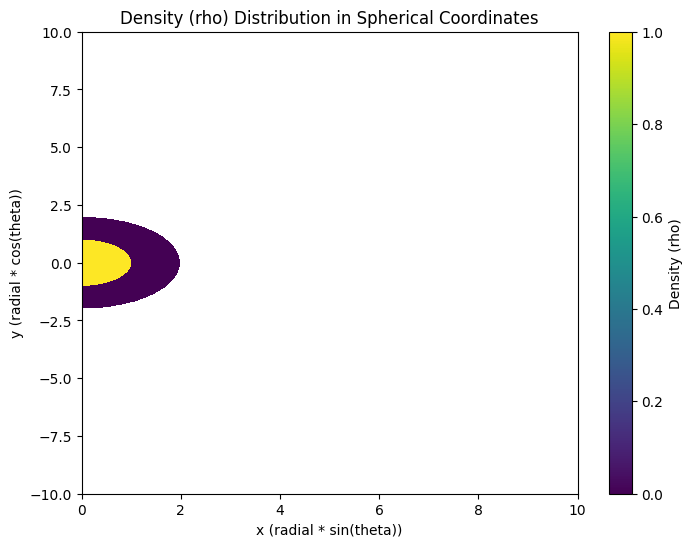

In [1080]:
import matplotlib.pyplot as plt
import numpy as np

# Plot colormap of rho
plt.figure(figsize=(8, 6))

# Create the colormap plot using pcolormesh
# Since theta goes from 0 to pi, you can convert it into x and y for visualization purposes
x = radius_grid * np.sin(theta_grid)
y = radius_grid * np.cos(theta_grid)
# Plot the colormap
plt.pcolormesh(x, y, (Br**2 + Bth**2 * radius_grid**2)**(1/2) * B_UNIT, cmap='viridis')

# Add labels and title
plt.xlabel('x (radial * sin(theta))')
plt.ylabel('y (radial * cos(theta))')
plt.title('Density (rho) Distribution in Spherical Coordinates')
plt.xlim(0,10)
plt.ylim(-10,10)
# Add a colorbar to indicate the values of rho
plt.colorbar(label='Density (rho)')
#plt.axis('equal')

# Display the plot
plt.show()


In [727]:
import inspect
import nmmn.sed

# Get the SED class
s = nmmn.sed.SED()

# Use inspect to get the source code of the grmonty method
print(inspect.getsource(s.grmonty))


	def grmonty(self, file):
		"""
		Reads SEDs in the format provided by grmonty. I ported the 
		original SM script `plspec.m` provided by J. Dolence. 
		"""
		# reads grmonty SED file
		self.file=file
		s=ascii.read(file, Reader=ascii.NoHeader)

		# carries out array conversions
		small = 1e-12
		ll0 = numpy.log10(s['col2']+small) + numpy.log10(3.83e33)
		ll1 = numpy.log10(s['col8']+small) + numpy.log10(3.83e33)
		ll2 = numpy.log10(s['col14']+small) + numpy.log10(3.83e33)
		ll3 = numpy.log10(s['col20']+small) + numpy.log10(3.83e33)
		ll4 = numpy.log10(s['col26']+small) + numpy.log10(3.83e33)
		ll5 = numpy.log10(s['col32']+small) + numpy.log10(3.83e33)
		lw = s['col1'] + numpy.log10(9.1e-28*3e10*3e10/6.626e-27)

		# gets log(nu) and log(nuLnu)
		self.lognu, self.ll = lw, ll5
		self.nu,self.nlnu = 10**self.lognu,10**self.ll
		
		# Checks if ll has NaN or Inf values
		self.check()



# Analytical Test

In [633]:
wgt_data = np.loadtxt('../gpumonty/wgt_values.txt')
F_data = np.loadtxt('../gpumonty/F_values.txt')
def linear_interp_weight(nu, wgt):
    lnu_max = np.log(1e18)
    lnu_min = np.log(1e7)
    dlnu = (lnu_max - lnu_min) / 200
    lnu = np.log(nu.copy())

    # Calculate the fractional index di and the integer index i
    di = (lnu - lnu_min) / dlnu
    i = np.floor(di).astype(int)
    di = di - i

    # Handle edge cases if nu is out of range
    mask = i <0
    i[mask] = 0
    di[mask] = 0

    mask2 = i >= 200
    i[mask2] = 200 -1
    di[mask2] = 1
    # Perform the linear interpolation
    return np.exp((1. - di) * wgt[i] + di * wgt[i + 1])


KMAX = 1e7
KMIN = 0.02  # Assuming a lower bound for KMIN, set according to your use case
KFAC = 9 * np.pi * ME * CL / EE  # Assuming ME, CL, and EE are defined elsewhere
dnmax =  3.166275e-49
N_ESAMP = 200
def GPU_linear_interp_F(K, F):
    print("in linear_interp")
    lK_min = np.log(KMIN)
    dlK = np.log(KMAX / KMIN) / N_ESAMP
    dlK = 1 / dlK
    
    lK = np.log(K)
    di = (lK - lK_min) * dlK
    i = np.floor(di).astype(int)  # Use np.floor and cast to int for array
    
    di = di - i  # Fractional part of di

    # Ensure that indices stay within bounds
    i = np.clip(i, 0, len(F) - 2)  # To avoid index out of range
    print("i = ", i, "di = ", di, "F[i] = ", F[i], "F[i+1] = ", F[i+1], "coeff = ", (1.0 - di) * F[i] + di * F[i + 1])
    # Perform the interpolation
    result = np.exp((1.0 - di) * F[i] + di * F[i + 1])
    
    return result

def GPU_F_eval(Thetae, Bmag, nu, F_data):
    # Convert nu to a NumPy array if it's not already
    nu = np.asarray(nu)

    # Compute K array for all elements in nu
    K = KFAC * nu / (Bmag * Thetae**2)

    # Initialize the result array
    result = np.zeros_like(K)

    # Case where K > KMAX
    mask_Kmax = K > KMAX
    result[mask_Kmax] = 0.0

    # Case where K < KMIN (approximation)
    mask_Kmin = K < KMIN
    x = K[mask_Kmin]**(1/3)
    result[mask_Kmin] = x * (37.67503800178 + 2.240274341836 * x)

    # Case where KMIN <= K <= KMAX (interpolation)
    mask_interp = (~mask_Kmax) & (~mask_Kmin)
    result[mask_interp] = GPU_linear_interp_F(K[mask_interp], F_data)

    return result


In [634]:
F_data

array([ 1.560527e+00,  1.597676e+00,  1.634808e+00,  1.671921e+00,
        1.709015e+00,  1.746087e+00,  1.783134e+00,  1.820156e+00,
        1.857149e+00,  1.894112e+00,  1.931040e+00,  1.967932e+00,
        2.004784e+00,  2.041592e+00,  2.078354e+00,  2.115065e+00,
        2.151721e+00,  2.188317e+00,  2.224849e+00,  2.261311e+00,
        2.297699e+00,  2.334005e+00,  2.370224e+00,  2.406349e+00,
        2.442372e+00,  2.478286e+00,  2.514083e+00,  2.549754e+00,
        2.585289e+00,  2.620679e+00,  2.655913e+00,  2.690979e+00,
        2.725865e+00,  2.760560e+00,  2.795048e+00,  2.829315e+00,
        2.863347e+00,  2.897127e+00,  2.930637e+00,  2.963859e+00,
        2.996774e+00,  3.029361e+00,  3.061598e+00,  3.093463e+00,
        3.124931e+00,  3.155976e+00,  3.186571e+00,  3.216688e+00,
        3.246296e+00,  3.275364e+00,  3.303857e+00,  3.331742e+00,
        3.358979e+00,  3.385532e+00,  3.411357e+00,  3.436413e+00,
        3.460653e+00,  3.484031e+00,  3.506497e+00,  3.527998e

In [9]:
photon_count = 2000000
nu = np.exp(np.random.rand(photon_count) * (np.log(1e18) - np.log(1e7)) + np.log(1e7))

# Calculate initial weights
weight = linear_interp_weight(nu, wgt_data)

# Start iterating until all weights satisfy the condition
random_numbers = np.random.rand(photon_count)

# Initial mask to check the condition for all photons
mask = random_numbers > GPU_F_eval(100, 1, nu, F_data) / (weight + 1e-100) / dnmax

while np.any(mask):
    # Re-sample nu values only for the entries that don't meet the criterion
    nu[mask] = np.exp(np.random.rand(np.sum(mask)) * (np.log(1e18) - np.log(1e7)) + np.log(1e7))

    # Recalculate the weights for the updated nu values
    weight[mask] = linear_interp_weight(nu[mask], wgt_data)

    # Generate new random numbers for the next iteration
    random_numbers[mask] = np.random.rand(np.sum(mask))

    # Recompute the mask for the updated nu and weights
    mask = random_numbers > GPU_F_eval(100, 1, nu, F_data) / (weight + 1e-100) / dnmax
    
ph_E = HPL *(nu) /(ME*CL**2)


In [10]:
#Now divide it into energy bins
lE = np.log(ph_E);
iE = np.floor((lE - np.log(1e-12)) / 0.25 + 2.5).astype(int) - 2

In [11]:
spectral = np.zeros((200))
domega =0.1482720
for i in range(200):
    if (iE[i] >=200 or iE[i] < 0):
        continue
    spectral[iE[i]] += weight[i] * ph_E[i]

for i in range(200):
    spectral[i] = ME * CL**2 * 4 * np.pi/(domega) * 1/0.25 * spectral[i]

# Create a mask for entries where s.lognu < 1e17 and spectral is zero
mask = (s.lognu < 1e17) & (spectral == 0)

# Filter out the values in spectral that are zero and where lognu < 1e17
filtered_spectral = spectral[~mask]

# If you want to also filter the corresponding s.lognu values
filtered_lognu = s.lognu[~mask]

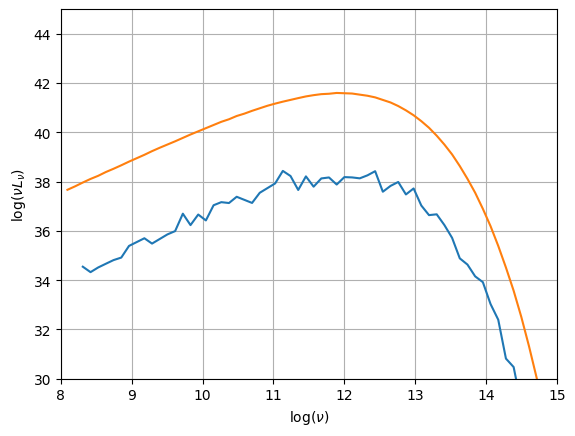

In [12]:
#from gpumonty
import nmmn.sed
import matplotlib.pyplot as plt

plt.xlim(8, 15)
plt.ylim(30,45)
plt.xlabel(r"$\log(\nu)$")
plt.ylabel(r"$\log(\nu L_\nu)$")
#plt.yticks([-10,-5,0,5])
plt.grid(True)
plt.plot(filtered_lognu, np.log10(filtered_spectral))
plt.plot(s.lognu, np.log10((10**s.ll)))


In [1867]:
spectral

array([2.37916897e+32, 1.25884369e+33, 1.80590518e+33, 0.00000000e+00,
       3.46026571e+33, 3.18807091e+33, 4.31069666e+33, 8.18973720e+33,
       0.00000000e+00, 0.00000000e+00, 1.79567867e+34, 1.48406228e+34,
       1.13258871e+34, 5.49385172e+34, 8.02844589e+34, 2.87156125e+34,
       7.57098111e+34, 1.00035487e+35, 2.10793402e+35, 1.81208826e+35,
       4.73286168e+35, 4.34982274e+35, 2.17564843e+35, 5.25698518e+35,
       3.60248633e+35, 0.00000000e+00, 5.59218582e+35, 2.00096771e+36,
       4.04985640e+36, 2.96667807e+36, 3.54270330e+36, 3.84691213e+36,
       3.02222929e+36, 3.20308306e+36, 3.39470751e+36, 1.77719832e+36,
       3.58520004e+36, 1.76411930e+36, 3.12958243e+36, 0.00000000e+00,
       3.74156010e+36, 1.00552914e+36, 3.91660116e+36, 2.12775071e+36,
       3.16719914e+35, 6.85749717e+35, 3.49357215e+35, 2.11008759e+35,
       0.00000000e+00, 1.94245284e+34, 6.45812583e+33, 0.00000000e+00,
       9.81910826e+32, 3.13206204e+32, 4.04997732e+31, 1.65492102e+31,
      

/tmp/ipykernel_557245/3542187113.py:18: RuntimeWarning: divide by zero encountered in log10
  plt.plot(s.lognu, np.log10(nu_luminosity_analytic), linestyle='-', marker='x', label = 'Analytical Solution')
/tmp/ipykernel_557245/3542187113.py:21: RuntimeWarning: divide by zero encountered in divide
  epsilon = 1/s.lognu * (np.abs(gpumonty_nulognu - nu_luminosity_analytic)/nu_luminosity_analytic * np.gradient(s.lognu)).sum(-1)


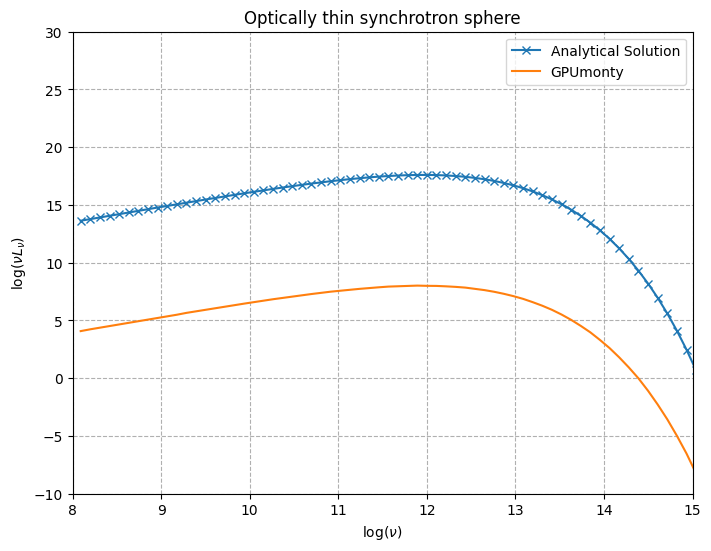

In [1645]:
# I = j_\nu L, where L is the path length of the photon, which I will consider L \approx 2R
s.grmonty('../gpumonty/output/spherical_test.specmake')
from scipy.special import kn
def jnu(ne, nu, B, thetae):
    sin_value = 0.9
    nus = (2/9) * (EE * B/(2 * np.pi * ME * CL)) * thetae**2 * sin_value
    X = nu/nus
    factor =  np.sqrt(2) * np.pi * EE**2 * ne * nus/(3 * CL * kn(2, 1/thetae))
    return factor * (X**(1/2) + 2**(11/12) * X**(1/6))**2 * np.exp(-X**(1/3))
# Frequency range from 1e8 Hz to 1e16 Hz (in logarithmic scale)
# Calculate synchrotron emissivity for each frequency
j_nu_values = jnu(1e15, 10**s.lognu, 1, 100)
sphere_radius = 100 * L_UNIT
Luminosity_analytic =  j_nu_values * (dx1 * dx2 * gdet).sum(-1).sum(-1) * L_UNIT
nu_luminosity_analytic = 10**s.lognu * Luminosity_analytic
# Plot jnu vs nu
plt.figure(figsize=(8, 6))
plt.plot(s.lognu, np.log10(nu_luminosity_analytic), linestyle='-', marker='x', label = 'Analytical Solution')
plt.plot(s.lognu, (s.ll - np.log10(3.83e33)), linestyle='-', label = 'GPUmonty')
gpumonty_nulognu = 10**(s.ll - np.log10(3.83e33))
epsilon = 1/s.lognu * (np.abs(gpumonty_nulognu - nu_luminosity_analytic)/nu_luminosity_analytic * np.gradient(s.lognu)).sum(-1)
plt.ylim(-10,30)
plt.xlim(8,15)
#plt.yticks([-10,-5,0,5])
plt.xlabel(r"$\log(\nu)$")
plt.legend()
plt.ylabel(r"$\log(\nu L_\nu)$")
plt.title('Optically thin synchrotron sphere')
plt.grid(True, which="both", ls="--")
plt.show()